**Θεωρητικό Μέρος**

α)Η Gaussian πυραμίδα υλοποιείται με τη χρήση ενός φίλτρου Kernel 5 επί 5 το οποίο αξιοποιείται με σκοπό την υποδειγματοληψία και το θόλωμα της εικόνας από το επίπεδο κ στο επίπεδο κ+1. Η τιμή του α διαδραματίζει καταλυτικό ρόλο στη διαδικασία αυτή καθώς καθορίζει το βάρος του κεντρικού pixel αλλά και τα υπόλοιπα βάρη του φίλτρου. Όσο μεγαλύτερη είναι η τιμή του α (π.χ α = 0.6) τόσο πιο οξύ και στενό είναι το σχήμα του φίλτρου με συνέπεια το κεντρικό pixel να αποκτά καίριο ρόλο και η εικόνα στο επόμενο επίπεδο να είναι αρκετά ευκρινής. Όσο μικρότερη είναι η τιμή του α η επιρροή μοιράζεται ομοιόμορφα στα διπλανά pixel με αποτέλεσμα το θόλωμα της εικόνας να είναι μεγαλύτερο. Μία τιμή του α που τηρεί την ισορροπία ανάμεσα στην ευκρίνεια και την εξομάλυνση είναι η τιμή 0.4 που προσεγγίζει την gaussian κατανομή

β)Ορίζουμε ως εντροπία το μέτρο της μέσης ποσότητας πληροφορίας που περιέχει μία εικόνα. Όταν η εντροπία είναι χαμηλή οι τιμές των pixel είναι προβλέψιμες και η συμπίεση της εικόνας είναι μεγαλύτερη. Αντιθέτως, όταν η εντροπία είναι μεγάλη τα pixels έχουν πολλές διαφορετικές τιμές με αποτέλεσμα η εικόνα να είναι δύσκολο να συμπιεστεί. Συνεπώς θεωρούμε ότι η εντροπία αποτελέι και το μέτρο της αβεβαιότητας. Σε μία greyscale εικόνα θεβρούμε ότι ένα pixel αποτελέιται από 8 bits, δηλαδή 2^8 = 256 τιμές φωτεινότητας (0-255). Λαμβάνοντας υπόψη τον τύπο της εντροπίας: $$H = -\sum_{i=0}^{255} f(i) \log_2 f(i)$$
Με λογαρίθμηση, χρήση πολλαπλασιαστών lagrange και παραγώγιση συμπεραίνουμε οως η μέγιστη εντροπία επιτυγχάνεται όταν όλες οι τιμές φωτεινότητας για κάθε pixel είναι ισοπίθανες, f(i) = 1/256. Το συμπέρασμα αυτό εξάγεται και διαισθητικά εφόσον τότε έχουμε και τη μέγιστη αβεβαιότητα.

γ)Ο κβαντισμός χωρίζει όλο το πιθανό έυρος τιμών που παράγονται από την λαπλασιανή πυραμίδα σε μικρότερα διαστήματα (bins). Τα pixels που ομαδοποιούνται στο ίδιο bin αντικαθιστώνται από μια ενιαία τιμή. Συνεπώς, αν επιλέξουμε μεγάλο μέγεθος bin τοποθετούμε πολλά δαφορετικά bin σε μία ομάδα μειώνοντας την αβεβαιότητα (εντροπία) και αυξάνοντας την συμπίεση. Παρόλα αυτά κατά την ανακατασκευή παρατηρούνται αλλοιώσεις καθώς πολλές λεπτομέρειες χάνονται. Από την άλλη πλευρά αν επιλέξουμε μικρό μέγεθος bin η συμπίεση είναι δυσκολότερη, όμως η ευκρίνεια της τελικής εικόνας θα είναι μεγαλύτερη.

δ)Το πλήθος των επιπέδων της Λαπλασιανής πυραμίδας επηρεάζει άμεσα τα αποτελέσματα της κβάντισης. Όταν διατηρούμε μεγάλο αριθμό επιπεδων στην πυραμίδα διαχωρίζονται καλύτερα τα χαρακτηριστικά υψηλών συχνοτήτων της εικόνας από τα χαρακτηριστικά χαμηλών συχνοτήτων. Έτσι στις υψηλές συχνότητες επιλέγουμε μεγάλο bin καθώς το ανθρώπινο μάτι δεν διακρίνει εύκολα τα σφάλματα στις λεπτομέρειες, ενώ στις χαμηλές συχνότητες επιλέγουμε μικρό μέγεθος bin καθώς τα σφάλματα εκεί είναι προφανέστερα. Αν ο αριθμός των επιπέδων είναι μικρός οι συχνότητες αναμειγνύονται μεταξύ τους και ο κβαντισμός δεν είναι δυνατό να πραγματοποιηθεί το ίδιο αποδοτικά.








In [ ]:
#Εργαστηριακό μέρος
#Υλοποίηση Αλγορίθμου
#1 Συνάρτηση GKernel
import numpy as np
def GKernel(a):
  w_0 = a #w(0)=a
  w_2 = 0.25 - a/2.0 #w(2)=w(-2), συμμετρία
  w_1 = 0.25 #w(1)=w(-1)
  w_1d = np.array([w_2, w_1, w_0, w_1, w_2]) #ο μονοδιάστατος πίνακας w
  h = np.outer(w_1d, w_1d) #ο συνολικός πίνακας w(m,n) = w(m)w(n) εκφράζεται ως εξωτερικό γινόμενο
  return h

#Παράδειγμα συνάρτησης GKernel
a_param = 0.4 #Gaussian καμπύλη, ιδανική περίπτωση
h_matrix = GKernel(a_param)

print(f"Δισδιάστατο Generating Kernel για a = {a_param}:\n")
np.set_printoptions(formatter={'float': '{: 0.4f}'.format})#ακρίβεια 4 δεκαδικών ψηφίων
print(h_matrix)

Δισδιάστατο Generating Kernel για a = 0.4:

[[ 0.0025  0.0125  0.0200  0.0125  0.0025]
 [ 0.0125  0.0625  0.1000  0.0625  0.0125]
 [ 0.0200  0.1000  0.1600  0.1000  0.0200]
 [ 0.0125  0.0625  0.1000  0.0625  0.0125]
 [ 0.0025  0.0125  0.0200  0.0125  0.0025]]


In [ ]:
#2 Συνάρτηση GREDUCE
import cv2

def GREDUCE(Image, h):
  image_float = Image.astype(np.float32)#μετατρέπουμε σε float για μεγαλύτερη ακρίβεια, για να μη χαθεί πληροφορία
  image_fil = cv2.filter2D(image_float, -1, h, borderType=cv2.BORDER_REFLECT)#συνέλιξη, εικόνα εξοδου ίσα κανάλια με εισόδου, καθρέυτης τελικών πιξελ
  I_out = image_fil[::2, ::2]#image = image/4, από την αρχή μέχρι το τέλος με βήμα 2
  return I_out #δε χρησιμοποιώ τη resize που αναφέρεται στα παραδείγματα γιατί δεν περιλεμβάνει τον kernel
  #ο kernel υπολογιζει τις νεες τιμες των πιξελ χρησιμοποιωντας ποσοστο δεδομενων απο τα γειτονικα πιξελ

#Παράδειγμα χρήσης της συνάρτησης
img= np.array([
    [3,106,107,40,148,112,254,151],
    [62,173,91,93,33,111,139,25],
    [99,137,80,231,101,204,74,219],
    [240,173,85,14,40,230,160,152],
    [230,200,177,149,173,239,103,74],
    [19,50,209,82,241,103,3,87],
    [252,191,55,154,171,107,6,123],
    [7,101,168,85,115,103,32,11]
], dtype=np.uint8)

h_matrix = GKernel(0.4)#φτιάχνω το φίλτρο
img_reduced = GREDUCE(img, h_matrix)#εφαρμογή του πυρήνα και της GREDUCE

print("Αποτέλεσμα GREDUCE")
np.set_printoptions(formatter={'float': '{: 0.2f}'.format})
print(img_reduced)

Αποτέλεσμα GREDUCE
[[ 59.91  95.45  105.46  153.81]
 [ 133.88  117.45  118.75  141.64]
 [ 166.49  140.54  147.38  122.57]
 [ 122.88  129.01  132.90  66.98]]


In [ ]:
#3 Συνάρτηση GPyramid
#Δημιουργία της Gaussian πυραμίδας
def GPyramid(I, a, depth):
  h = GKernel(a)#δημιουργω τον πινακα w(m,n)
  G = [I] #Ι=εικόνα και η βάση της πυραμίδας είναι η ίδια η εικόνα
  for i in range(depth-1): #depth ο αριθμος των επιπεδων της πυραμίδας Gaussian
    current_layer = G[i] #παιρνουμε το τελευταιο στοιχείο του πινακα G
    next_layer = GREDUCE(current_layer, h) #υποδειγματοληπτουμε και φιλτραρουμε
    G.append(next_layer)#προσθετουμε το επομενο layer στον πινακα G
  return G
#Παράδειγμα εκτέλεσης της συνάρτησης
img_ex = np.random.randint(0, 256, (512, 512), dtype=np.uint8)#παραγω τυχαιους αριθμου απο το 0 - 256 με διαστασεις 512 x 512
#ορίζω τις παραμέτρους και καλω την συναρτηση
gaussian_pyramid = GPyramid(img_ex, 0.4, 5)
print("Διαστάσεις επιπέδων Gaussian Πυραμίδας:")
for i, layer in enumerate(gaussian_pyramid):
    print(f"Επίπεδο G{i}: {layer.shape}")
#παρατηρούμε ότι έχει γίνει σωστά η υποδειγματοληψία των πινάκων όπως αναμέναμε

Διαστάσεις επιπέδων Gaussian Πυραμίδας:
Επίπεδο G0: (512, 512)
Επίπεδο G1: (256, 256)
Επίπεδο G2: (128, 128)
Επίπεδο G3: (64, 64)
Επίπεδο G4: (32, 32)


In [ ]:
def GEXPAND(I, h):
    im_float = I.astype(np.float32)
    new_shape = list(im_float.shape)#μετατροπη σε float για να μη χαθει πληροφορια
    new_shape[0] *= 2#διπλασιάζουμε τις γραμμές
    new_shape[1] *= 2#Διπλασιάζουμε τις στήλες
    im_expanded = np.zeros(new_shape, dtype=np.float32)
    im_expanded[::2, ::2] = im_float#στις αρτιες θεσεις κραταμε τις τιμες

    h_interp = h * 4.0
    I_out = cv2.filter2D(im_expanded, -1, h_interp, borderType=cv2.BORDER_REFLECT)
    return I_out

In [ ]:
#5 Συνάρτηση Λαπλασιανής πυραμίδας
def LPyramid(I, a, depth):
    h = GKernel(a) #Δημιουργώ τον kernel
    G = GPyramid(I, a, depth) #Δημιουργώ την Γκαουσιανή πυραμίδα
    L = [] #δημιουργώ κενη λίστα για την Λαπλασιανή πυραμίδα
    for i in range(depth - 1):
        current_g = G[i] #G[n] = current layer G
        next_g = G[i+1] #G[n+1] = next layer G
        interpol_g = GEXPAND(next_g, h)
        current_g_float = current_g.astype(np.float32)
        laplacian_layer = current_g_float - interpol_g #L[n]=G[n] - expanded(G[n+1])
        L.append(laplacian_layer)
    L.append(G[-1])
    return L

In [ ]:
#6 Συνάρτηση L_Pyramid_Decode
import numpy as np
def L_Pyramid_Decode(L,a):
  h = GKernel(a)
  im_current = L[-1].copy()#το τελευταίο στοιχείο της λίστας της Λαπλασιανής πυραμίδας
  for i in range(len(L) - 2, -1, -1):#μετράμε από κάτω προς τα πανω στην πυραμίδα
      im_expanded = GEXPAND(im_current, h)#κανει expand στην τρέχουσα εικόνα
      rows, cols = L[i].shape[:2]
      im_expanded = im_expanded[:rows, :cols]
      im_current = L[i] + im_expanded#αντιστροφη εξίσωση

  Im_out = im_current
  return Im_out


In [ ]:
#7 Συνάρτηση L_Quantization
def L_Quantization(L, q_step):
  Level_quantized = [] #αποθηκευω τα κβαντισμενα επιπεδα σε αυτη τη λιστα

  for i in range(len(L)): #διατρεχω όλα ατα επιπεδα της πυραμίδας
    if i == len(L) - 1:
      Level_quantized.append(L[i])#δεν καντιζουμε το τελευταιο επιπεδο γτ ειναι ηδη πολυ θολό
      continue
    quantized_level = np.round(L[i] / q_step) * q_step#εδω γινεται η κβαντιση
    Level_quantized.append(quantized_level)
  return Level_quantized

In [ ]:
from skimage import data
camera_image = data.camera()

In [ ]:
from skimage import io
from skimage import color
url = "http://www.image.ntua.gr/~tpar/LABimage/lena.png"
lena_image = io.imread(url)

In [ ]:
#Μέρος Β
#Ερώτημα 1
import matplotlib.pyplot as plt
a_param = 0.4
depth = 5
#Ξεκινάμε με τη lena
print(f"Lena(Έγχρωμη) - Διαστάσεις: {lena_image.shape}")
#Δημιουργία Λαπλασιανής πυραμίδας για τη Λένα
Laplacian_pyr_lena = LPyramid(lena_image, a_param, depth)
#Ανακατασκευή της πυραμίδας για τη Λένα
reconstructed_lena = L_Pyramid_Decode(Laplacian_pyr_lena, a_param)
#Σφάλματα για τη Λένα
lena_error = np.mean(np.abs(lena_image.astype(np.float32) - reconstructed_lena))
print(f"Μέσο απόλυτο σφάλμα ανακατασκευής: {lena_error}")
print(f"Μέσο απόλυτο σφάλμα ανακατασκευής με ακρίβεια 5 δεκαδικών ψηφίων: {lena_error:.5f}")




Lena(Έγχρωμη) - Διαστάσεις: (512, 512, 3)
Μέσο απόλυτο σφάλμα ανακατασκευής: 4.630540839656305e-09
Μέσο απόλυτο σφάλμα ανακατασκευής με ακρίβεια 5 δεκαδικών ψηφίων: 0.00000


In [ ]:
#Συνεχίζουμε με την ασπρόμαυρη εικόνα την camera
print(f"Camera (Grayscale) - Διαστάσεις: {camera_image.shape}")
#Δημιουργία Λαπλασιανής πυραμίδας για την κάμερα
Laplacian_pyr_camera = LPyramid(camera_image, a_param, depth)
reconstructed_camera = L_Pyramid_Decode(Laplacian_pyr_camera, a_param)
#Σφάλματα για την κάμερα
camera_error= np.mean(np.abs(camera_image.astype(np.float32) - reconstructed_camera))
print(f"Μέσο απόλυτο σφάλμα ανακατασκευής: {camera_error}")
print(f"Μέσο απόλυτο σφάλμα ανακατασκευής με ακρίβεια 5 δεκαδικών ψηφίων: {camera_error:.5f}")




Camera (Grayscale) - Διαστάσεις: (512, 512)
Μέσο απόλυτο σφάλμα ανακατασκευής: 1.4090801414567977e-08
Μέσο απόλυτο σφάλμα ανακατασκευής με ακρίβεια 5 δεκαδικών ψηφίων: 0.00000


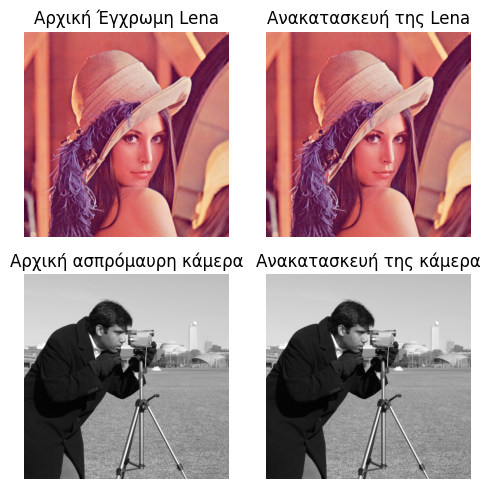

In [ ]:
#Οπτικοποίηση του πρώτου ερωτήματος
lena_clipped = np.clip(reconstructed_lena, 0, 255).astype(np.uint8) #κόβω τιμές αρνητικές και τιμές μεγαλύτερες του 255
camera_clipped = np.clip(reconstructed_camera, 0, 255).astype(np.uint8)
fig, axes = plt.subplots(2, 2, figsize=(5, 5))#Προτετοιμασία του γραφήματος
#Εμφάνιση της Lena
axes[0, 0].imshow(lena_image)
axes[0, 0].set_title("Αρχική Έγχρωμη Lena")
axes[0, 0].axis('off')
axes[0, 1].imshow(lena_clipped)
axes[0, 1].set_title("Ανακατασκευή της Lena")
axes[0, 1].axis('off')
#Εμφάνιση της Camera
axes[1, 0].imshow(camera_image, cmap='gray')
axes[1, 0].set_title("Αρχική ασπρόμαυρη κάμερα")
axes[1, 0].axis('off')
axes[1, 1].imshow(camera_clipped, cmap='gray')
axes[1, 1].set_title("Ανακατασκευή της κάμερα")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

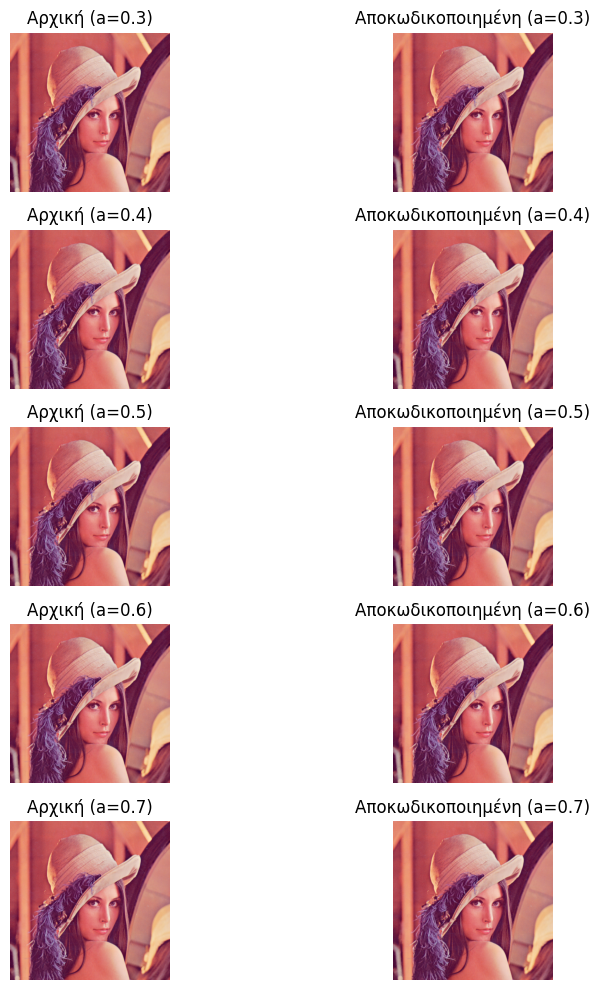

In [ ]:
#Ερώτημα 2
#Δημιουργώ την πυραμίδα και την ανακατασκευή της εικόνας για διαφορετικές τιμές του α
a_values = [0.3,0.4,0.5,0.6,0.7]
depth = 5
fig, axes = plt.subplots(len(a_values), 2, figsize=(10, 10))
def Laplacian_and_reconstruct_for_a_values(image, a_val):
    Laplacian_pyr_image =  LPyramid(image, a_val, depth)
    reconstructed_image = L_Pyramid_Decode(Laplacian_pyr_image, a_val)
    reconstructed_clipped = np.clip(reconstructed_image, 0, 255).astype(np.uint8)
    return reconstructed_clipped

image_1 = lena_image
for i, a in enumerate(a_values):
    axes[i, 0].imshow(image_1.astype(np.uint8))
    axes[i, 0].set_title(f"Αρχική (a={a})")
    axes[i, 0].axis('off')
    final_reconstructed_image_1 = Laplacian_and_reconstruct_for_a_values(image_1, a)
    axes[i, 1].imshow(final_reconstructed_image_1)
    axes[i, 1].set_title(f"Αποκωδικοποιημένη (a={a})")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()


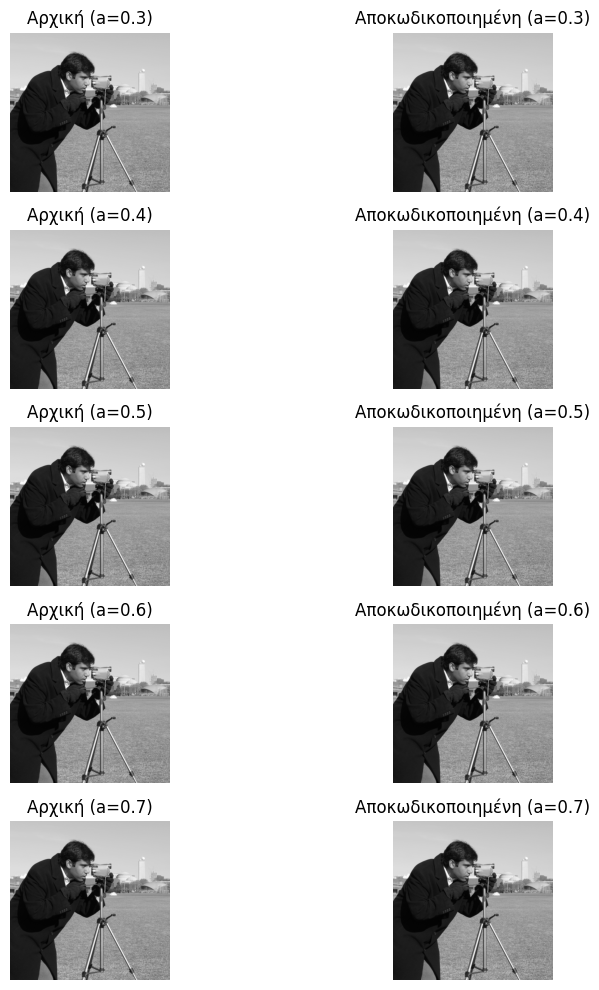

In [ ]:
#Ερώτημα 2 για την κάμερα
image_2 = camera_image
fig, axes = plt.subplots(len(a_values), 2, figsize=(10, 10))
for i, a in enumerate(a_values):
    axes[i, 0].imshow(image_2.astype(np.uint8),cmap='gray')
    axes[i, 0].set_title(f"Αρχική (a={a})")
    axes[i, 0].axis('off')
    final_reconstructed_image_2 = Laplacian_and_reconstruct_for_a_values(image_2, a)
    axes[i, 1].imshow(final_reconstructed_image_2,cmap='gray')
    axes[i, 1].set_title(f"Αποκωδικοποιημένη (a={a})")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

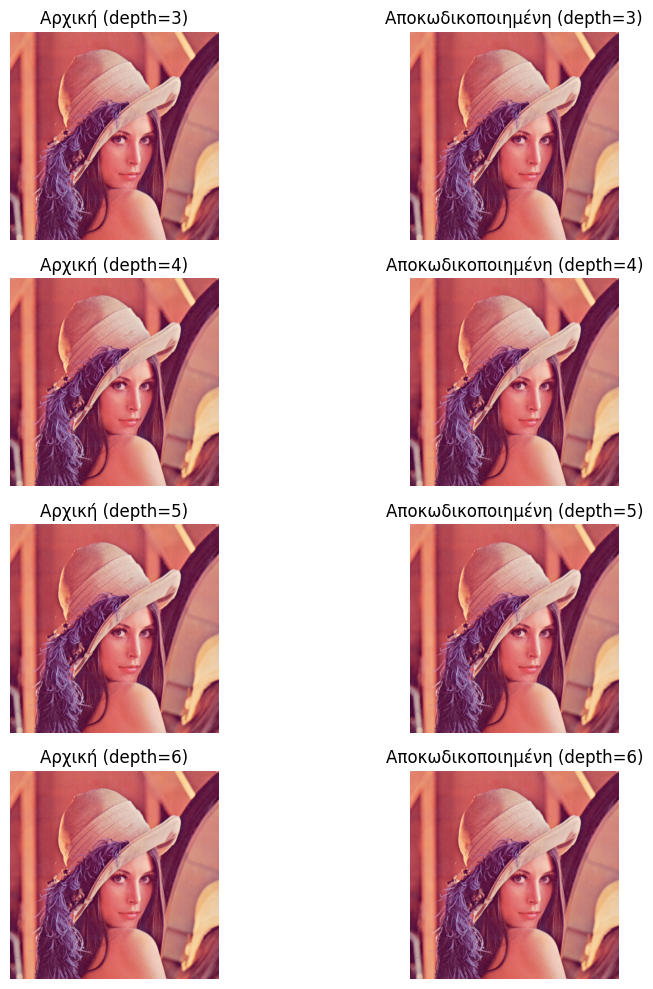

In [ ]:
#Ερώτημα 3
#Δημιουργώ την πυραμίδα και την ανακατασκευή της εικόνας για διαφορετικές τιμές του depth
a_param = 0.4
depth_values = [3, 4, 5, 6]
fig, axes = plt.subplots(len(depth_values), 2, figsize=(10, 10))
def Laplacian_and_reconstruct_for_a_values(image, depth_val):
    Laplacian_pyr_image =  LPyramid(image, a_param, depth_val)
    reconstructed_image = L_Pyramid_Decode(Laplacian_pyr_image, a_param)
    reconstructed_clipped = np.clip(reconstructed_image, 0, 255).astype(np.uint8)
    return reconstructed_clipped

for i, d in enumerate(depth_values):
    axes[i, 0].imshow(image_1.astype(np.uint8))
    axes[i, 0].set_title(f"Αρχική (depth={d})")
    axes[i, 0].axis('off')
    final_reconstructed_image_1 = Laplacian_and_reconstruct_for_a_values(image_1, d)
    axes[i, 1].imshow(final_reconstructed_image_1)
    axes[i, 1].set_title(f"Αποκωδικοποιημένη (depth={d})")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

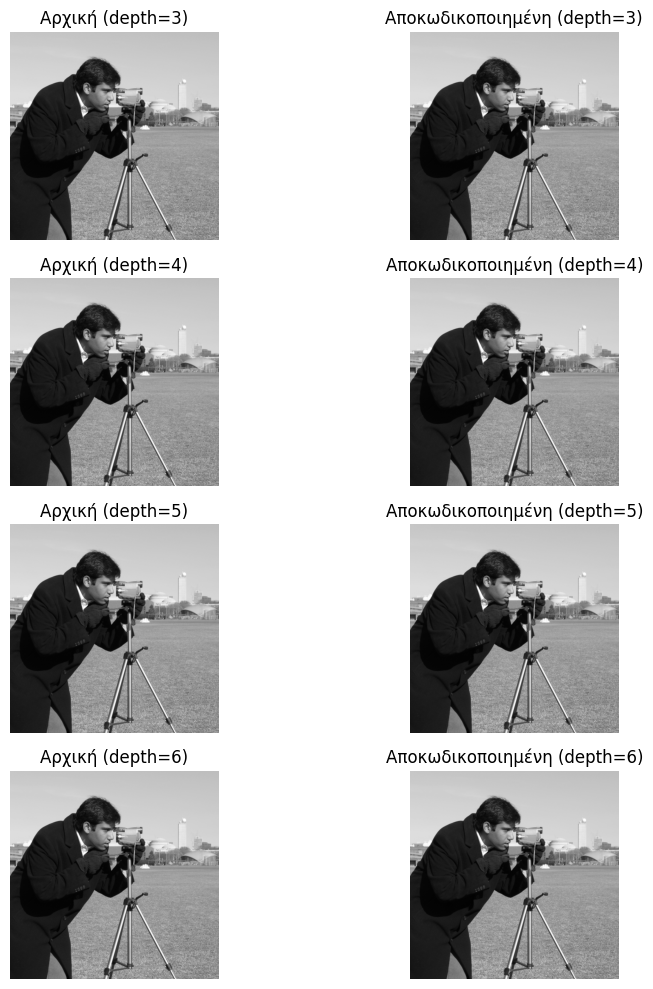

In [ ]:
#Επαναλαμβάνω το τρίτο ερώτημα για την εικόνα κάμερα
fig, axes = plt.subplots(len(depth_values), 2, figsize=(10, 10))
for i, d in enumerate(depth_values):
    axes[i, 0].imshow(image_2.astype(np.uint8), cmap = 'grey')
    axes[i, 0].set_title(f"Αρχική (depth={d})")
    axes[i, 0].axis('off')
    final_reconstructed_image_2 = Laplacian_and_reconstruct_for_a_values(image_2, d)
    axes[i, 1].imshow(final_reconstructed_image_2, cmap = 'grey')
    axes[i, 1].set_title(f"Αποκωδικοποιημένη (depth={d})")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
#Ερώτημα 4 - Εντροπία για διαφορετικά α και depth
def compute_pyramid_entropy(l_pyramid):
  sum_hist = np.zeros([256, 1], np.float64)#δημιουργω εναν κενό πίνακα 256x1 και τον γεμίζω μηδενικά
  for n, level in enumerate(l_pyramid):#παίρνω όλα τα επίπεδα της πυραμίδας από κάτω προς τα πάνω
    if n < len(l_pyramid) - 1:#ελέγχω αν βρίσκομαι σε ενδιάμεσοεπίπεδο της πυραμίδας
        level_adjusted = np.clip(level + 128, 0, 255).astype(np.uint8)#τοποθετούμε όλα τα σφάλματα στο διάστημα 0-255
    else:
        level_adjusted = np.clip(level, 0, 255).astype(np.uint8)#εδώ κανω μετατροπή σε ακέραιους
    hist = cv2.calcHist([level_adjusted], [0], None, [256], [0, 256])#εδώ υπολογίζω τη συχνότητα εμφάνισης κάθε τιμής
    sum_hist += hist #το συνολικόάθροισμα
  sum_hist = sum_hist / sum_hist.sum()#κανονικοποίηση στο 0-1
  entropy = -np.sum(sum_hist * np.log2(sum_hist + 1e-10))#υπλογίζω την εντροπία
  return entropy



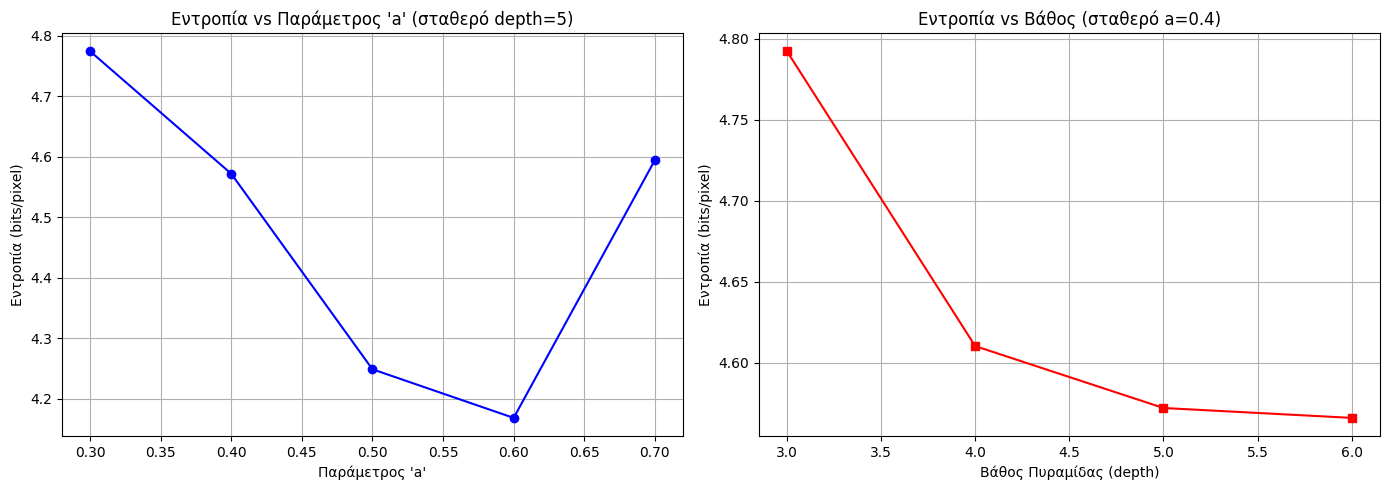

In [ ]:
entropy_a=[]
entropy_depth=[]
for a in a_values:
  pyramid_a = LPyramid(image_1, a, 5)
  entropy_a.append(compute_pyramid_entropy(pyramid_a))
for d in depth_values:
  pyramid_d = LPyramid(image_1,0.4,d)
  entropy_depth.append(compute_pyramid_entropy(pyramid_d))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(a_values, entropy_a, marker='o', color='b', linestyle='-')
axes[0].set_title("Εντροπία vs Παράμετρος 'a' (σταθερό depth=5)")
axes[0].set_xlabel("Παράμετρος 'a'")
axes[0].set_ylabel("Εντροπία (bits/pixel)")
axes[0].grid(True)
axes[1].plot(depth_values, entropy_depth, marker='s', color='r', linestyle='-')
axes[1].set_title("Εντροπία vs Βάθος (σταθερό a=0.4)")
axes[1].set_xlabel("Βάθος Πυραμίδας (depth)")
axes[1].set_ylabel("Εντροπία (bits/pixel)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Η εντροπία εκφράζει την πιθανότητα να πετύχω κάποια τιμή φωτεινότητας σε ένα pixel. Για την εικόνα lena η τιμή του α = 0.6 πετυχαίνει τις καλύτερες προβλέψεις των γειτονικών pixel, συνεπώς μειώνεται η αβεβαιότητα και επιτυγχάνεται η βέλτιστη συμπίεση. Όσο αφορά το βάθος της πυραμίδας (depth) όσο μεγακύτερο είναι τόσο καλύτερη συμπίεση έχουμε. Παρόλα αυτά, μετά την τιμή depth = 5 παρατηρούμε ότι η καμπύλη μεταβάλεται ελάχιστα καθώς η εικόνα στην κορυφή της πυραμίδας είναι μικροσκοπική με αποτέλεσμα η περεταίρω υποδειγματοληψία της να μην προσφέρει βελτίωση της εντροπίας.

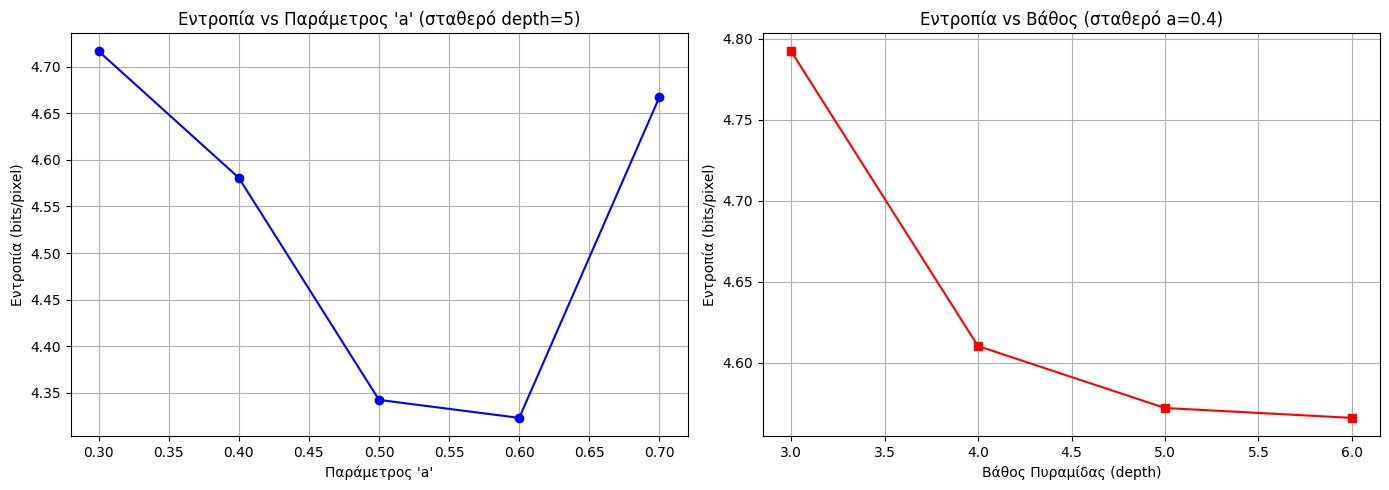

In [ ]:
entropy2_a=[]
entropy2_depth=[]
for a in a_values:
  pyramid_a = LPyramid(image_2, a, 5)
  entropy2_a.append(compute_pyramid_entropy(pyramid_a))
for d in depth_values:
  pyramid_d = LPyramid(image_1,0.4,d)
  entropy2_depth.append(compute_pyramid_entropy(pyramid_d))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(a_values, entropy2_a, marker='o', color='b', linestyle='-')
axes[0].set_title("Εντροπία vs Παράμετρος 'a' (σταθερό depth=5)")
axes[0].set_xlabel("Παράμετρος 'a'")
axes[0].set_ylabel("Εντροπία (bits/pixel)")
axes[0].grid(True)
axes[1].plot(depth_values, entropy2_depth, marker='s', color='r', linestyle='-')
axes[1].set_title("Εντροπία vs Βάθος (σταθερό a=0.4)")
axes[1].set_xlabel("Βάθος Πυραμίδας (depth)")
axes[1].set_ylabel("Εντροπία (bits/pixel)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Επίπεδο 0: Βέλτιστο a = 0.60 (με Εντροπία = 3.9518)
Επίπεδο 1: Βέλτιστο a = 0.55 (με Εντροπία = 4.2502)
Επίπεδο 2: Βέλτιστο a = 0.55 (με Εντροπία = 4.9567)
Επίπεδο 3: Βέλτιστο a = 0.50 (με Εντροπία = 5.7588)
Επίπεδο 4: Βέλτιστο a = 0.30 (με Εντροπία = 6.8342)


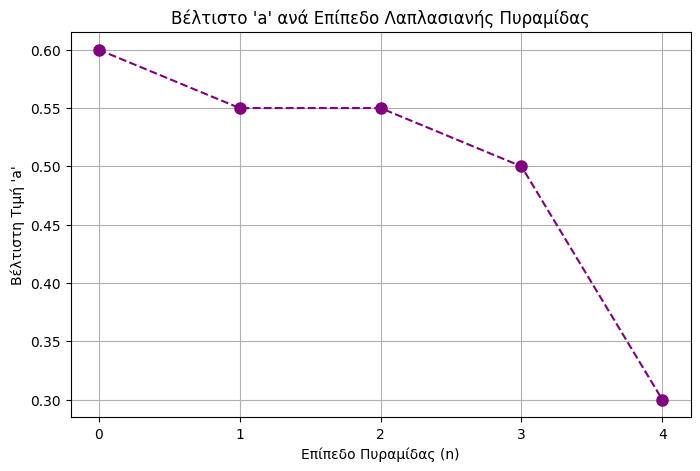

In [ ]:
#Ερώτημα 5 - Εντροπία για κάθε επίπεδο ξεχωριστά
def compute_level_entropy(level_image, is_top_level):
    if not is_top_level:#ομοια διαδικασια με πριν
        level_adjusted = np.clip(level_image + 128, 0, 255).astype(np.uint8)
    else:
        level_adjusted = np.clip(level_image, 0, 255).astype(np.uint8)
    hist = cv2.calcHist([level_adjusted], [0], None, [256], [0, 256])
    hist = hist / hist.sum()
    entropy = -np.sum(hist * np.log2(hist + 1e-10))
    return entropy

a_values = np.arange(0.3, 0.7, 0.05)

optimal_a_level = []
min_entropies = []
#Διατρέχουμε κάθε επίπεδο n
for n in range(5):
    best_a = None
    min_entropy = float('inf')
    for a in a_values:
        pyr = LPyramid(image_1, a, 5)
        current_level = pyr[n]
        is_top = (n == 4)
        ent = compute_level_entropy(current_level, is_top)
        if ent < min_entropy:
            min_entropy = ent
            best_a = a

    optimal_a_level.append(best_a)
    min_entropies.append(min_entropy)

    print(f"Επίπεδο {n}: Βέλτιστο a = {best_a:.2f} (με Εντροπία = {min_entropy:.4f})")
plt.figure(figsize=(8, 5))
plt.plot(range(depth), optimal_a_level, marker='o', color='purple', linestyle='dashed', markersize=8)
plt.title("Βέλτιστο 'a' ανά Επίπεδο Λαπλασιανής Πυραμίδας")
plt.xlabel("Επίπεδο Πυραμίδας (n)")
plt.ylabel("Βέλτιστη Τιμή 'a'")
plt.xticks(range(depth))
plt.grid(True)
plt.show()

Στο παραπάνω ερώτημα συγκρίναμε την εντροπία που προκύπτει για διαφορετικές τιμές του α στο ίδιο επίπεδο. Έτσι συμπεραίνουμε πως σε κάθε επίπεδο λειτουργεί ιδανικά διαφορετική τιμή του α, ακόμη κι αν πρακτικά επιλέγουμε ένα για όλα τα επίπεδα. Στις υψηλότερες συχνότητες χρειαζόμαστε μεγακύτερη τιμή α για σωστή πρόβλεψη ενώ στις χαμηλότερες που περιέχεται γενική πληροφορία αρκεί μικρή τιμή του α. Τελικά, επιλέγουμε το α που είναι βέλτιστη για το επίπεδο L0 στο οποίο περιέχεται και η περισσότερη πληροφορία.

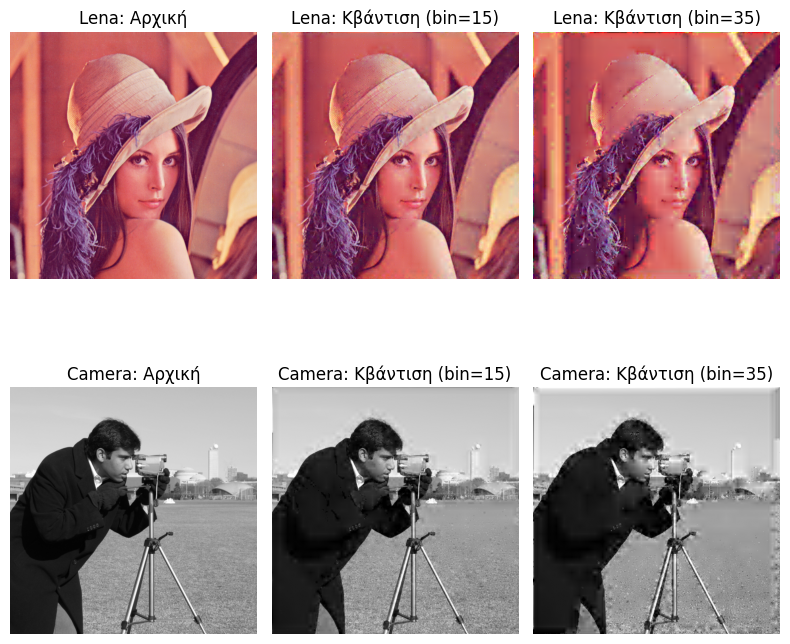

In [ ]:
#Eρώτημα 6-Κβαντισμός
q_step1 = 15
q_step2 = 35
#Ξεκιναω με τη λενα
lena_pyramid = LPyramid(image_1, 0.6, 5)
camera_pyramid = LPyramid(image_2, 0.6, 5)
#κβαντισμος για διαφορετικα bin
quantized_pyr_lena_1 = L_Quantization(lena_pyramid, q_step1)
quantized_pyr_lena_2 = L_Quantization(lena_pyramid, q_step2)
quantized_pyr_camera_1 = L_Quantization(camera_pyramid, q_step1)
quantized_pyr_camera_2 = L_Quantization(camera_pyramid, q_step2)
#Reconstruction
rec_lena_1 = L_Pyramid_Decode(quantized_pyr_lena_1, 0.6)
rec_lena_2 = L_Pyramid_Decode(quantized_pyr_lena_2, 0.6)
rec_camera_1 = L_Pyramid_Decode(quantized_pyr_camera_1, 0.6)
rec_camera_2 = L_Pyramid_Decode(quantized_pyr_camera_2, 0.6)

#Κλιπάρισμα για σωστή εμφάνιση
rec_lena_1_clipped = np.clip(rec_lena_1, 0, 255).astype(np.uint8)
rec_lena_2_clipped = np.clip(rec_lena_2, 0, 255).astype(np.uint8)
rec_camera_1_clipped = np.clip(rec_camera_1, 0, 255).astype(np.uint8)
rec_camera_2_clipped = np.clip(rec_camera_2, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(2, 3, figsize=(8, 8))

#Λενα
axes[0, 0].imshow(image_1.astype(np.uint8), cmap='gray')
axes[0, 0].set_title("Lena: Αρχική")
axes[0, 0].axis('off')

axes[0, 1].imshow(rec_lena_1_clipped, cmap='gray')
axes[0, 1].set_title(f"Lena: Κβάντιση (bin={q_step1})")
axes[0, 1].axis('off')

axes[0, 2].imshow(rec_lena_2_clipped, cmap='gray')
axes[0, 2].set_title(f"Lena: Κβάντιση (bin={q_step2})")
axes[0, 2].axis('off')

#Camera
axes[1, 0].imshow(image_2.astype(np.uint8), cmap='gray')
axes[1, 0].set_title("Camera: Αρχική")
axes[1, 0].axis('off')

axes[1, 1].imshow(rec_camera_1_clipped, cmap='gray')
axes[1, 1].set_title(f"Camera: Κβάντιση (bin={q_step1})")
axes[1, 1].axis('off')

axes[1, 2].imshow(rec_camera_2_clipped, cmap='gray')
axes[1, 2].set_title(f"Camera: Κβάντιση (bin={q_step2})")
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


Όπως είναι φανερό όσο μεγαλύτερο είναι το μέγεθος του bin τόσο χειροτερεύει η ευκρίνεια της εικόνας, καθώς τα pixels που ανήκουν στο ίδιο bin αντικαθίστανται από την ίδια τιμή.